In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_trade_log(df):
    """
    Scans the vectorized backtest DataFrame, groups the 1s and 0s into 
    discrete trades, and calculates the win rate and average profit.
    """
    pos = df['Position'].fillna(0)
    changes = pos.diff()
    
    # Grab the exact dates from the Index where changes happen
    entries = df[changes == 1].index
    exits = df[changes == -1].index
    
    # Force-close any open positions at the end of the dataset
    if len(entries) > len(exits):
        exits = exits.append(pd.Index([df.index[-1]]))
        
    trade_ledger = []
    
    for entry_date, exit_date in zip(entries, exits):
        
        # Calculate compounded return for this specific holding period
        trade_returns = df.loc[entry_date:exit_date, 'Strategy_Return']
        trade_profit = (1 + trade_returns).prod() - 1
        
        # Calculate holding period (Calendar Days vs Trading Days)
        calendar_days = (exit_date - entry_date).days
        trading_days = df.index.get_loc(exit_date) - df.index.get_loc(entry_date)
        
        trade_ledger.append({
            'Entry_Date': entry_date,
            'Exit_Date': exit_date,
            'Trading_Days': trading_days,
            'Calendar_Days': calendar_days,
            'Return': trade_profit
        })

    return pd.DataFrame(trade_ledger)

def compute_insights(df, ticker):
    """Calculates performance metrics and returns them as a dictionary, along with the trade ledger."""
    
    now = pd.Timestamp.now().strftime('%Y-%m-%d')
    start_date = df.index[0]
    end_date = df.index[-1]
    total_asset_return = df['Asset_Equity'].iloc[-1] - 1
    total_strategy_return = df['Strategy_Equity'].iloc[-1] - 1

    # Generate the Trade Log
    trades_df = extract_trade_log(df)

    # Calculate the Holy Grail Metrics
    if len(trades_df) > 0:

        metrics = {
            "Simulation_Date": now,
            "Ticker": ticker,
            "Start_Date": start_date.strftime('%Y-%m-%d'),
            "End_Date": end_date.strftime('%Y-%m-%d'),
            "Total_Trading_Days": int(len(df)),
            "Total_Trades_Taken": int(len(trades_df)),
            "Buy_Hold_Return": float(total_asset_return),
            "Strategy_Return": float(total_strategy_return),
            "Performance_Delta": float(total_strategy_return - total_asset_return),
            "Win_Rate": 0.0,
            "Average_Win": 0.0,
            "Average_Loss": 0.0,
            "Best_Trade": 0.0,
            "Worst_Trade": 0.0
        }

        winning_trades = trades_df[trades_df['Return'] > 0]
        losing_trades = trades_df[trades_df['Return'] <= 0]

        metrics["Win_Rate"] = float(len(winning_trades) / len(trades_df))
        metrics["Average_Win"] = float(winning_trades['Return'].mean()) if not winning_trades.empty else 0.0
        metrics["Average_Loss"] = float(losing_trades['Return'].mean()) if not losing_trades.empty else 0.0
        metrics["Best_Trade"] = float(trades_df['Return'].max())
        metrics["Worst_Trade"] = float(trades_df['Return'].min())
        
        print(f"\n=== TRADE LOG SUMMARY ===")
        print(f"Start Date:         {metrics["Start_Date"]}")
        print(f"End Date:           {metrics["End_Date"]}")
        print(f"Total Trading Days: {len(df)}")
        print(f"Total Trades Taken: {len(trades_df)}")
        print(f"Win Rate:           {metrics["Win_Rate"]:.2%}")
        print(f"Average Win:        {metrics["Average_Win"]:.2%}")
        print(f"Average Loss:       {metrics["Average_Loss"]:.2%}")
        print(f"Best Trade:         {trades_df['Return'].max():.2%}")
        print(f"Worst Trade:        {trades_df['Return'].min():.2%}")
        print("=========================\n")

        print(f"=== {ticker} BASELINE BACKTEST RESULTS ===")
        print(f"Total Trading Days: {len(df)}")
        print(f"Buy & Hold Return:  {total_asset_return:.2%}")
        print(f"Strategy Return:    {total_strategy_return:.2%}")
        print(f"Performance Delta:  {(total_strategy_return - total_asset_return):.2%}")
        print("=========================================\n")    

        return metrics, df
    else:
        print("\n[!] No trades executed during this period.")

        return None, df
    
def plot_equity_curve(df, ticker):
    """Visualizes the backtest using the DatetimeIndex."""
    plt.figure(figsize=(12, 6))
    
    # Replaced df['Date'] with df.index
    plt.plot(df.index, df['Asset_Equity'], label='Buy & Hold', color='gray', alpha=0.7)
    plt.plot(df.index, df['Strategy_Equity'], label='RSI 35/65 Strategy', color='blue', linewidth=2)
    
    plt.title(f'{ticker} - Baseline Strategy Equity Curve')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (1.0 = 100%)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_signals(df, ticker):
    """
    Plots the asset price, moving averages, and overlays the exact 
    Buy (Green ^) and Sell (Red v) signals generated by the strategy.
    """
    plt.figure(figsize=(14, 7))

    # Plot the Main Price Line
    plt.plot(df.index, df['Adj Close'], label='Price', color='black', alpha=0.5, linewidth=1.5)

    # Plot the Moving Averages

    plt.plot(df.index, df['SMA_20'], label='SMA 20', color='blue', alpha=0.6, linestyle='--')
    plt.plot(df.index, df['SMA_50'], label='SMA 50', color='orange', alpha=0.6, linestyle='--')

    # Pinpoint the exact Trade Execution days
    changes = df['Position'].diff()
    buy_signals = df[changes == 1]
    sell_signals = df[changes == -1]

    # Overlay the Signal Arrows
    # marker='^' is an up arrow, 'v' is a down arrow.
    # zorder=5 forces the arrows to render on top of the price lines.
    plt.scatter(buy_signals.index, buy_signals['Adj Close'], 
                marker='^', color='green', label='Buy Signal', s=120, zorder=5)
    
    plt.scatter(sell_signals.index, sell_signals['Adj Close'], 
                marker='v', color='red', label='Sell Signal', s=120, zorder=5)

    # Make it look professional
    plt.title(f'{ticker} - Strategy Executions & Moving Averages', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [46]:
ticker = "MSFT"
interval = "daily"
start_date_string = "2020-01-01"
end_date_string = None

raw_path = f"../../../data/raw/{ticker}/{interval}/data.parquet"
features_path = f"../../../data/features/{ticker}/{interval}/data.parquet"
insights_path = f"../../../data/insights/{ticker}/{interval}/baseline_results.parquet"

In [47]:
def lake_read_parquet(data_path, start_date=None, end_date=None):
    insights_df = pd.read_parquet(data_path, engine='pyarrow')
    insights_df['Date'] = pd.to_datetime(insights_df['Date'])
    insights_df.set_index('Date', inplace=True)

    if not start_date and not end_date:
        return insights_df
    elif not end_date:
        start_dt = pd.to_datetime(start_date)
        return insights_df[insights_df.index >= start_dt]
    else:
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)
        return insights_df[(insights_df.index >= start_dt) & (insights_df.index <= end_dt)].copy()

In [48]:
data = lake_read_parquet(features_path, start_date_string, end_date_string)
data.head()

,Ticker,Adj Close,Close,High,Low,Open,Volume,RSI,SMA_20,SMA_50,EMA_20,MACD,MACD_Signal,MACD_Hist
Date,,,,,,,,,,,,,,
2020-02-03,MSFT,165.570557,174.380005,174.500000,170.399994,170.429993,30107000,66.682891,156.622636,NaN,157.722485,2.494351,1.644634,0.849716
2020-02-04,MSFT,171.020538,180.119995,180.639999,176.309998,177.139999,36433300,70.753557,157.623862,NaN,158.988966,3.236884,1.963084,1.273800
2020-02-05,MSFT,170.811707,179.899994,184.199997,178.410004,184.029999,39186300,73.540073,158.683483,NaN,160.114941,3.765094,2.323486,1.441608
2020-02-06,MSFT,174.353256,183.630005,183.820007,180.059998,180.970001,27751400,75.350588,159.801024,NaN,161.470971,4.418544,2.742498,1.676046
2020-02-07,MSFT,174.600113,183.889999,185.630005,182.479996,182.850006,33529100,77.794465,160.835960,NaN,162.721366,4.899844,3.173967,1.725877


In [49]:
def generate_signals_tier1(df):
    df = df.copy()
    
    df['SMA_20'] = df['Adj Close'].rolling(window=20).mean()
    df['Asset_Return'] = df['Adj Close'].pct_change()  
    positions = np.zeros(len(df))
    strategy_returns = np.zeros(len(df))
    
    in_position = False
    entry_price = 0.0
    
    # Use .values for much faster iteration
    close_prices = df['Adj Close'].values
    rsi_values = df['RSI'].values
    sma_values = df['SMA_20'].values
    
    for i in range(1, len(df)):
        # Skip if indicators aren't ready
        if np.isnan(rsi_values[i-1]) or np.isnan(sma_values[i-1]):
            continue
            
        current_price = close_prices[i]
        prev_price = close_prices[i-1]
        prev_rsi = rsi_values[i-1]
        prev_sma = sma_values[i-1]
        
        if not in_position:
            # We want RSI oversold, but price should be near or above SMA to show 'dip in uptrend'
            # If 35 is too strict, we'll try 40.
            if prev_rsi < 35 and current_price > (prev_sma * 0.98): 
                in_position = True
                entry_price = current_price
                positions[i] = 1
        
        elif in_position:
            # Calculate return from the entry price
            unrealized_return = (current_price - entry_price) / entry_price
            
            # EXIT 1: Profit Target (+2%)
            if unrealized_return >= 0.02:
                in_position = False
                # We exit at the target price
                exit_price = entry_price * 1.02
                strategy_returns[i] = (exit_price / prev_price) - 1
                positions[i] = 0
                
            # EXIT 2: Stop Loss (-1%)
            elif unrealized_return <= -0.01:
                in_position = False
                # We exit at the stop price
                exit_price = entry_price * 0.99
                strategy_returns[i] = (exit_price / prev_price) - 1
                positions[i] = 0
                
            else:
                # Still holding
                positions[i] = 1
                strategy_returns[i] = (current_price / prev_price) - 1

    df['Position'] = positions
    df['Strategy_Return'] = strategy_returns
    
    return df

In [50]:
tier1_df = generate_signals_tier1(data)
tier1_df.head()

,Ticker,Adj Close,Close,High,Low,Open,Volume,RSI,SMA_20,SMA_50,EMA_20,MACD,MACD_Signal,MACD_Hist,Asset_Return,Position,Strategy_Return
Date,,,,,,,,,,,,,,,,,
2020-02-03,MSFT,165.570557,174.380005,174.500000,170.399994,170.429993,30107000,66.682891,NaN,NaN,157.722485,2.494351,1.644634,0.849716,NaN,0.0,0.0
2020-02-04,MSFT,171.020538,180.119995,180.639999,176.309998,177.139999,36433300,70.753557,NaN,NaN,158.988966,3.236884,1.963084,1.273800,0.032916,0.0,0.0
2020-02-05,MSFT,170.811707,179.899994,184.199997,178.410004,184.029999,39186300,73.540073,NaN,NaN,160.114941,3.765094,2.323486,1.441608,-0.001221,0.0,0.0
2020-02-06,MSFT,174.353256,183.630005,183.820007,180.059998,180.970001,27751400,75.350588,NaN,NaN,161.470971,4.418544,2.742498,1.676046,0.020734,0.0,0.0
2020-02-07,MSFT,174.600113,183.889999,185.630005,182.479996,182.850006,33529100,77.794465,NaN,NaN,162.721366,4.899844,3.173967,1.725877,0.001416,0.0,0.0


In [51]:
# Calculate Returns
tier1_df['Asset_Return'] = tier1_df['Adj Close'].pct_change()
tier1_df['Strategy_Return'] = tier1_df['Asset_Return'] * tier1_df['Position']

# Calculate Equity Curves
tier1_df['Asset_Equity'] = (1 + tier1_df['Asset_Return']).cumprod().fillna(1.0)
tier1_df['Strategy_Equity'] = (1 + tier1_df['Strategy_Return']).cumprod().fillna(1.0)

tier1_df.head()

,Ticker,Adj Close,Close,High,Low,Open,Volume,RSI,SMA_20,SMA_50,EMA_20,MACD,MACD_Signal,MACD_Hist,Asset_Return,Position,Strategy_Return,Asset_Equity,Strategy_Equity
Date,,,,,,,,,,,,,,,,,,,
2020-02-03,MSFT,165.570557,174.380005,174.500000,170.399994,170.429993,30107000,66.682891,NaN,NaN,157.722485,2.494351,1.644634,0.849716,NaN,0.0,NaN,1.000000,1.0
2020-02-04,MSFT,171.020538,180.119995,180.639999,176.309998,177.139999,36433300,70.753557,NaN,NaN,158.988966,3.236884,1.963084,1.273800,0.032916,0.0,0.0,1.032916,1.0
2020-02-05,MSFT,170.811707,179.899994,184.199997,178.410004,184.029999,39186300,73.540073,NaN,NaN,160.114941,3.765094,2.323486,1.441608,-0.001221,0.0,-0.0,1.031655,1.0
2020-02-06,MSFT,174.353256,183.630005,183.820007,180.059998,180.970001,27751400,75.350588,NaN,NaN,161.470971,4.418544,2.742498,1.676046,0.020734,0.0,0.0,1.053045,1.0
2020-02-07,MSFT,174.600113,183.889999,185.630005,182.479996,182.850006,33529100,77.794465,NaN,NaN,162.721366,4.899844,3.173967,1.725877,0.001416,0.0,0.0,1.054536,1.0


In [52]:
# Compute metrics
metrics_dict, trades_df = compute_insights(tier1_df, ticker)


=== TRADE LOG SUMMARY ===
Start Date:         2020-02-03
End Date:           2026-02-20
Total Trading Days: 1521
Total Trades Taken: 11
Win Rate:           100.00%
Average Win:        3.47%
Average Loss:       0.00%
Best Trade:         10.13%
Worst Trade:        0.67%

=== MSFT BASELINE BACKTEST RESULTS ===
Total Trading Days: 1521
Buy & Hold Return:  139.92%
Strategy Return:    45.06%
Performance Delta:  -94.85%



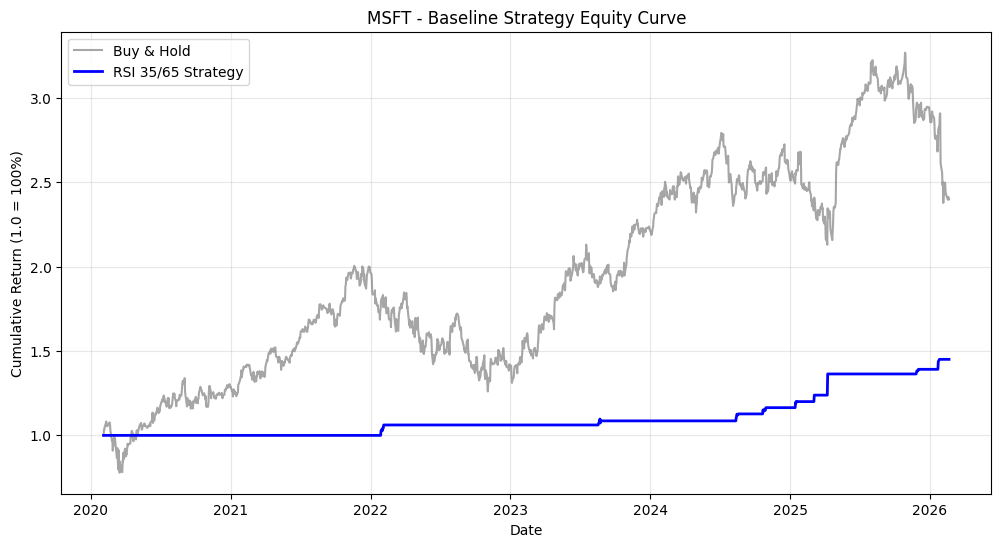

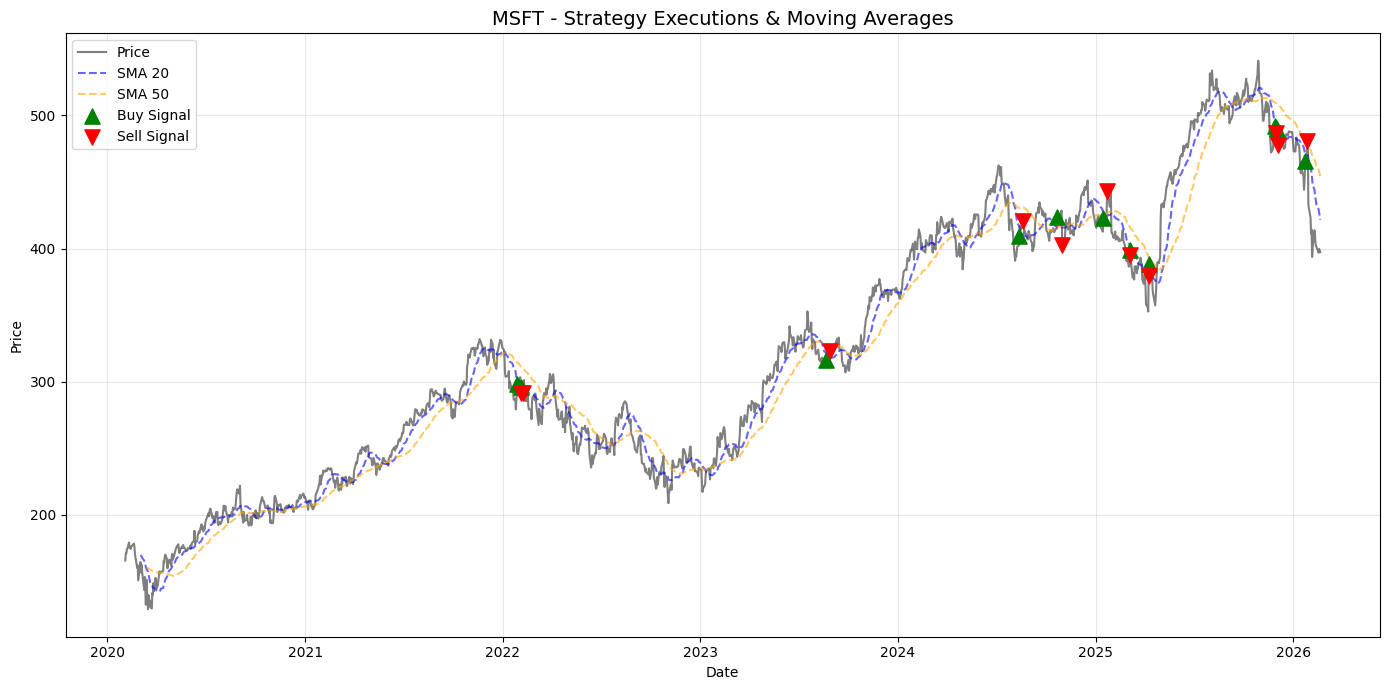

In [53]:
plot_equity_curve(tier1_df, ticker)
plot_signals(tier1_df, ticker)